# 01 — Análise Exploratória do MNIST

O **MNIST** é um conjunto de 70.000 imagens em tons de cinza de dígitos manuscritos
(0 a 9), cada uma com **28×28 pixels**: 60.000 para treino e 10.000 para teste.
É o "Hello, World!" da visão computacional.

Objetivo desta análise: **conhecer os dados antes de modelar** — quantos exemplos
por classe, como são as imagens e qual a "cara média" de cada dígito.

> Documentação complementar sobre o dataset em `docs/`.

In [1]:
# ── Setup — funciona igual no seu PC e no Google Colab ───────────────────────
# Ajuste REPO_URL após publicar o projeto no GitHub (ver README).
import sys, os, subprocess
from pathlib import Path

REPO_URL = "https://github.com/4rth-g/mnist-fundamentos-ia.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # No Colab não há o repositório: clonamos para ter o código de src/ e as pastas.
    if not Path("mnist-fundamentos-ia").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("mnist-fundamentos-ia")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

# Torna o pacote src/ importável (local: rodando de notebooks/; Colab: da raiz).
_root = Path.cwd()
_src = _root / "src" if (_root / "src").exists() else _root.parent / "src"
sys.path.insert(0, str(_src))
print("src/ em:", _src)

src/ em: /home/arthurg/Projetos_Dev/mnist-fundamentos-ia/src


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_mnist, seed_everything, FIGURES_DIR

sns.set_theme(style="whitegrid")
seed_everything()

# Carregamos SEM normalizar, para visualizar as imagens na escala natural (0–1).
train_full, test = load_mnist(normalize=False)
print(f"Treino: {len(train_full)} imagens | Teste: {len(test)} imagens")
print(f"Formato de uma imagem: {train_full[0][0].shape}  (canais × altura × largura)")
print(f"Classes: {train_full.classes}")

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

Treino: 60000 imagens | Teste: 10000 imagens
Formato de uma imagem: torch.Size([1, 28, 28])  (canais × altura × largura)
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## Distribuição das classes

Um dataset **balanceado** (classes com frequências parecidas) evita que o modelo
fique enviesado para os dígitos mais comuns. Vamos conferir.

/tmp/claude-1000/ipykernel_81503/230535400.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(train_full.targets)


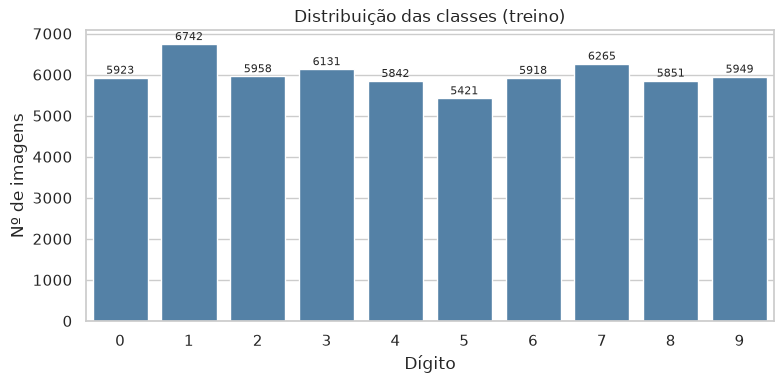

Menos frequente: dígito 5 (5421) | Mais frequente: dígito 1 (6742)
Dataset aproximadamente balanceado — diferença < 20% entre classes.


In [3]:
labels = np.array(train_full.targets)
counts = np.bincount(labels)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=list(range(10)), y=counts, ax=ax, color="steelblue")
ax.set(title="Distribuição das classes (treino)", xlabel="Dígito", ylabel="Nº de imagens")
for i, c in enumerate(counts):
    ax.text(i, c + 100, str(c), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_distribuicao_classes.png", dpi=120)
plt.show()

print(f"Menos frequente: dígito {counts.argmin()} ({counts.min()}) | "
      f"Mais frequente: dígito {counts.argmax()} ({counts.max()})")
print("Dataset aproximadamente balanceado — diferença < 20% entre classes.")

## Amostras de cada classe

Como cada dígito realmente se parece? Mostramos alguns exemplos por classe para
ter noção da **variação de estilos de escrita**.

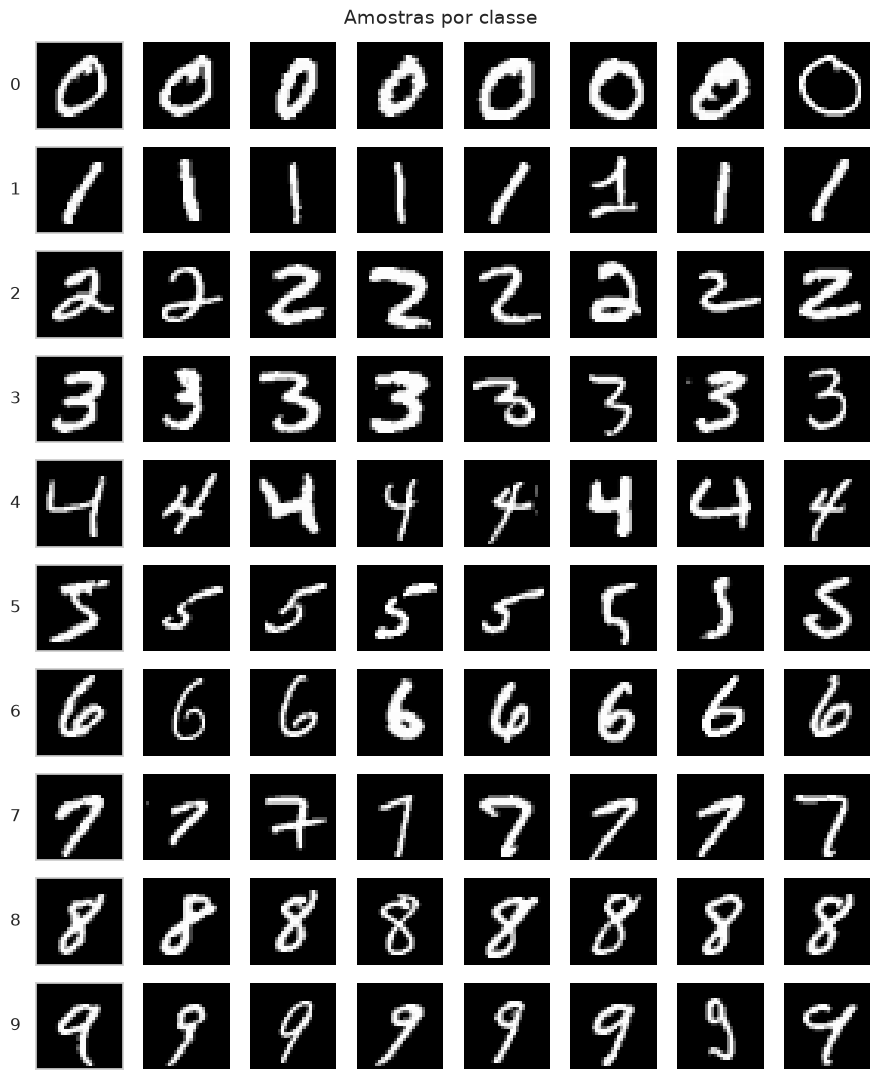

In [4]:
fig, axes = plt.subplots(10, 8, figsize=(9, 11))
for digit in range(10):
    idxs = np.where(labels == digit)[0][:8]
    for col, idx in enumerate(idxs):
        ax = axes[digit, col]
        ax.imshow(train_full[idx][0].squeeze(), cmap="gray")
        ax.axis("off")
    axes[digit, 0].set_ylabel(str(digit), rotation=0, labelpad=15,
                              fontsize=12, va="center")
    axes[digit, 0].axis("on"); axes[digit, 0].set_xticks([]); axes[digit, 0].set_yticks([])
fig.suptitle("Amostras por classe", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_amostras_por_classe.png", dpi=120)
plt.show()

## Imagem média de cada dígito

Tirando a média de todas as imagens de um dígito, aparece um "protótipo" borrado.
Dígitos com formas variadas (como o **4** e o **7**) ficam mais difusos — uma pista
de que serão os mais confundidos pelo modelo depois.

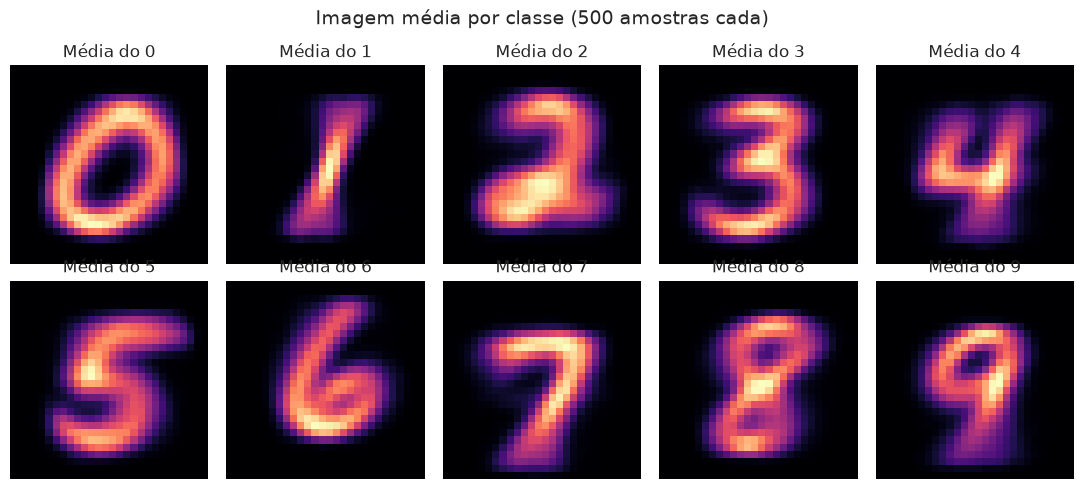

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit, ax in enumerate(axes.flat):
    mean_img = np.stack([train_full[i][0].numpy() for i in np.where(labels == digit)[0][:500]]).mean(0)
    ax.imshow(mean_img.squeeze(), cmap="magma")
    ax.set_title(f"Média do {digit}")
    ax.axis("off")
fig.suptitle("Imagem média por classe (500 amostras cada)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_media_por_classe.png", dpi=120)
plt.show()

## Conclusões da EDA

- **70.000 imagens 28×28** em tons de cinza, 10 classes.
- Dataset **aproximadamente balanceado** → acurácia é uma métrica adequada.
- Há **variação de estilo** dentro de cada dígito; as imagens médias sugerem que
  pares como **4/9** e **3/5/8** podem ser mais confundidos.
- Próximo passo (`02_cnn.ipynb`): treinar uma **CNN** para classificar os dígitos.